In [ ]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [ ]:
import os


import numpy as np
from dask.distributed import LocalCluster,Client

from libraries import AEM_preproc,SigNULL

import matplotlib.pyplot as plt

import warnings
from bokeh.util.warnings import BokehUserWarning

import pandas as pd
# Silence the visualization warnings
warnings.simplefilter("ignore", BokehUserWarning)

In [2]:
DFILE = r"J:\GWater\schoningg\RTO\data\All_AVG_export.gz.parquet"
GEXFILE = r"J:\GWater\schoningg\RTO\data\20230616_10098_306HP_LM_MergeGates_HM_splinegates_final_Z_V3.gex"
Survey = AEM_preproc.Survey()
Survey.proc_gex(GEXFILE)

Survey.add_data(DFILE)
Survey.lm_times = Survey.lm_times #-Surve\\y.lm_shift
Survey.hm_times = Survey.hm_times  #- Survey.hm_shift
lineno = 105601
times = Survey.time_list(line=lineno)
time = times[109]


In [ ]:
X,Y
901884.0,6971585.6

(np.float64(901884.0), np.float64(6971585.6))

In [4]:

X= 917594.654	
Y= 6965419.767

dist=np.sqrt(((Survey.Data.station_data.UTMX-X)**2+(Survey.Data.station_data.UTMY-Y)**2))
Survey.Data.station_data['dist']=dist
lineno,time=Survey.Data.station_data['dist'].idxmin()


In [4]:
# --- Setup Parameters ---
inv_thickness = np.logspace(np.log10(1), np.log10(15.0), 59)
# 1. Create the sounding object
isounding = SigNULL.Sounding(Survey, lineno, time, inv_thickness)
X=isounding.UTMX
Y=isounding.UTMY
SHARP=pd.read_csv(r"data\OGIA_LCI_Sharp_MOD_inv.xyz",delim_whitespace=True)
dist2=np.sqrt(((SHARP.UTMX-X)**2+(SHARP.UTMY-Y)**2))
SHARP=SHARP[dist2==dist2.min()]
thick=SHARP[SHARP.columns[-61:-31]].iloc[0].values
depth=thick.cumsum()
SHARPcon=SHARP[SHARP.columns[75:105]].values[0]/1000

C:\Users\SchoningG\AppData\Local\Temp\3\ipykernel_7480\2954803524.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  SHARP=pd.read_csv(r"data\OGIA_LCI_Sharp_MOD_inv.xyz",delim_whitespace=True)


In [14]:
cluster = LocalCluster(n_workers=64)
client = Client(cluster)
# --- Initialize Dask ---
N_REALS = 500  # HRML typically requires fewer reals than IES for stability
print(f"Dask Dashboard available at: {client.dashboard_link}")
# --- Run Inversion ---
print(f"Starting HRML Inversion for Line {lineno}...")
# 2. Run the HRML solver
isounding.get_HRML_reals(nreals=N_REALS, client=client)

# 3. Export results using your existing output utility
#output_path = f"./output/Line_{lineno}_Time_{time}"
#SigNULL.proc_output((time, isounding), output_path)

print("Inversion and export complete.")

j:\GWater\ENVS\ProbEM\lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55839 instead
  warnings.warn(
j:\GWater\ENVS\ProbEM\lib\contextlib.py:142: UserWarning: Creating scratch directories is taking a surprisingly long time. (5.76s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Dask Dashboard available at: http://127.0.0.1:55839/status
Starting HRML Inversion for Line 105601...
Scattering lightweight arrays...


KeyboardInterrupt: 

In [ ]:
isounding.RML.chivals

[1.1422787809076582,
 1.2297151289838073,
 1.2890725003515013,
 1.0993799304352316,
 1.3110327161292297,
 0.9987536288935972,
 1.3054965710420496,
 1.4174503577476272,
 1.3416640421900035,
 1.1870423422968919,
 1.0270105035399193,
 1.2719618560542063,
 1.3202394055163875,
 0.9982488732895467,
 0.9989605473817481,
 1.1551731405457222,
 1.4282009907488902,
 1.2624685297951364,
 1.1576870932122738,
 1.344718763863881,
 1.3439257196002472,
 0.965206807616484,
 1.4107608711996351,
 1.164248814471107,
 1.3151293274940279,
 1.9354886758743066,
 1.5614186291252485,
 0.9999590038761688,
 1.0709305843010142,
 1.706685379718338,
 8.466787496949228,
 1.0846547423924013,
 0.9987434670579127,
 1.1318781984243083,
 0.9999466710816746,
 1.0619724928399166,
 1.3560924428156926,
 0.9974478574132074,
 1.2569549211743027,
 1.5018668581609598,
 0.96924158816253,
 1.2681824207248475,
 1.086204307736912,
 1.063602858264107,
 1.0515180858886888,
 1.0923832317740454,
 0.9517350005206517,
 0.9998970742013933,
 

In [ ]:
client.close()
cluster.close()


In [ ]:
# --- Setup Parameters ---
inv_thickness = np.logspace(np.log10(1), np.log10(15.0), 59)
N_REALS = 2000  # HRML typically requires fewer reals than IES for stability

# --- Initialize Dask ---
cluster = LocalCluster(n_workers=64)
client = Client(cluster)
print(f"Dask Dashboard available at: {client.dashboard_link}")
# --- Run Inversion ---
print(f"Starting HRML Inversion for Line {lineno}...")

# 1. Create the sounding object
isounding1 = SigNUL.SSounding(Survey, lineno, time, inv_thickness)

# 2. Run the HRML solver
isounding1.get_IES_reals(nreals=N_REALS, client=client)



print("Inversion and export complete.")

2026-02-22 00:06:36,439 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\tornado\websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\tornado\web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\bokeh\server\views\ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary
2026-02-22 00:06:38,447 - tornado.application - ERROR - Uncaught

Dask Dashboard available at: http://127.0.0.1:8787/status
Starting HRML Inversion for Line 104801...


2026-02-22 00:06:50,465 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\tornado\websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\tornado\web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\bokeh\server\views\ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary


NameError: name 'SigNULL_SIMPEG' is not defined

2026-02-22 00:07:06,941 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\tornado\websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\tornado\web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
  File "j:\GWater\ENVS\ProbEM\lib\site-packages\bokeh\server\views\ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary


In [ ]:
client.close()
cluster.close()

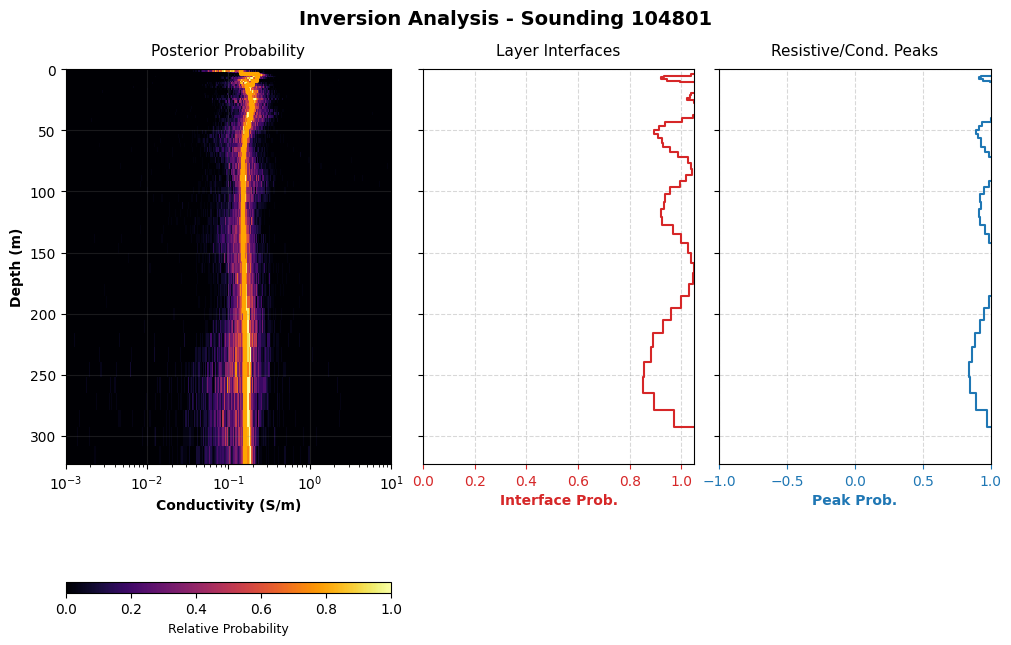

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup Data (Preserving logic) ---
# Create bins for conductivity (log spaced)
cond_bins = np.logspace(np.log10(0.001), np.log10(10), 300)

# Create mesh for pcolormesh (corners of the quadrilaterals)
X_mesh, Y_mesh = np.meshgrid(cond_bins, isounding.Depths)

def get_density_matrix(calreals, depths, bins):
    # Initialize matrix (n_layers, n_bins)
    d_mat = np.zeros((len(depths) - 1, len(bins) - 1))
    
    # Iterate through layers
    for j in range(len(depths) - 1):
        hist, _ = np.histogram(calreals[:, j], bins=bins)
        # Normalize: divide by max to get relative probability (0 to 1)
        d_mat[j, :] = hist / (np.max(hist) + 1e-9)
        
    return d_mat

post_density = get_density_matrix(np.array(isounding.RML.calreals), isounding.Depths, cond_bins)

# --- 2. Create 3-Panel Plot ---
# specific styling for reports
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.titlesize': 11,
    'axes.labelsize': 10
})

# Use width_ratios: [1.2, 1, 1] makes the PDF slightly wider than the others, 
# but "less wide" compared to the previous version which was 2:1.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6), sharey=True, constrained_layout=True, 
                                    gridspec_kw={'width_ratios': [1.2, 1, 1]})

# --- Panel 1: Posterior Conductivity Density ---
pcm = ax1.pcolormesh(
    X_mesh, Y_mesh, post_density, 
    cmap="inferno",  # '_r' reverses it (light is high prob), often cleaner for print
    shading="flat", 
    vmin=0, vmax=1,
    rasterized=True
)

ax1.set_xscale('log')
ax1.set_xlim(0.001, 10)
ax1.set_ylim(isounding.Depths.max(), 0) # Invert Y (0 at top)

ax1.set_ylabel("Depth (m)", fontweight='bold')
ax1.set_xlabel("Conductivity (S/m)", fontweight='bold')
ax1.set_title("Posterior Probability", pad=10)
ax1.grid(True, which="major", color="gray", alpha=0.2, linestyle="-")

ax1.step(SHARPcon,depth,c='orange',lw=3,label='Sharp inversion')
# Add Colorbar inside Panel 1
cbar = fig.colorbar(pcm, ax=ax1, orientation='horizontal', pad=0.15, aspect=30)
cbar.set_label("Relative Probability", fontsize=9)


# --- Panel 2: Interface Probability (IGP) ---
# Step plot for discrete layers
ax2.step(isounding.RML.igp, isounding.Depths, where='post', color='#d62728', linewidth=1.5)

ax2.set_xlabel("Interface Prob.", color='#d62728', fontweight='bold')
ax2.set_xlim(0, 1.05)
ax2.tick_params(axis='x', colors='#d62728')
ax2.grid(True, which="major", color="gray", alpha=0.3, linestyle="--")
ax2.set_title("Layer Interfaces", pad=10)


# --- Panel 3: Peak Probability ---
# Step plot for discrete layers
ax3.step(isounding.RML.sfi, isounding.Depths, where='post', color='#1f77b4', linewidth=1.5)

ax3.set_xlabel("Peak Prob.", color='#1f77b4', fontweight='bold')
ax3.set_xlim(-1, 1)
ax3.tick_params(axis='x', colors='#1f77b4')
ax3.grid(True, which="major", color="gray", alpha=0.3, linestyle="--")
ax3.set_title("Resistive/Cond. Peaks", pad=10)


# Add a shared title for the whole figure
fig.suptitle(f"Inversion Analysis - Sounding {isounding.iline}", fontsize=14, fontweight='bold', y=1.05)

plt.show()

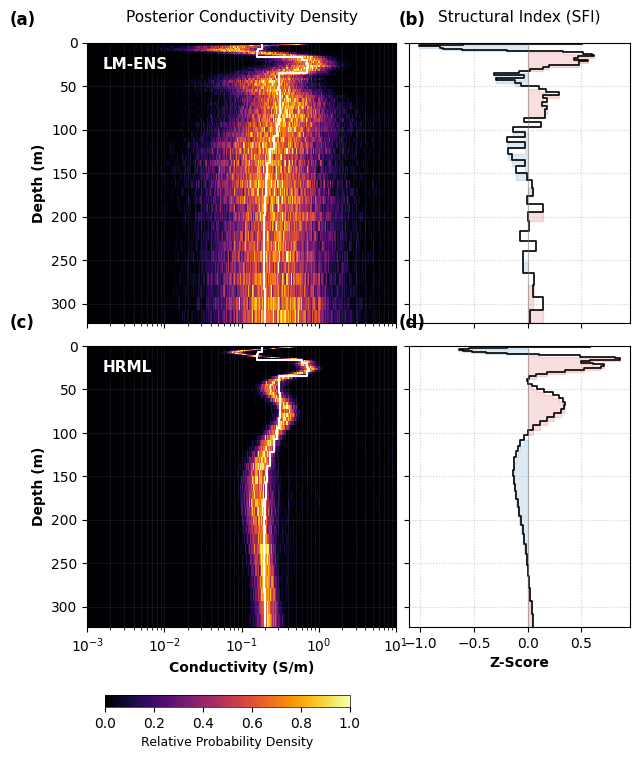

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def get_density_matrix(calreals, depths, bins):
    d_mat = np.zeros((len(depths) - 1, len(bins) - 1))
    for j in range(len(depths) - 1):
        hist, _ = np.histogram(calreals[:, j], bins=bins)
        d_mat[j, :] = hist / (np.max(hist) + 1e-9)
    return d_mat

def plot_comparison_paper_v2(ies_sounding, hrml_sounding):
    # Academic style settings
    plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})
    
    fig, axes = plt.subplots(2, 2, figsize=(7, 8), sharey=True, sharex='col',
                             gridspec_kw={'width_ratios': [1.4, 1.0], 'hspace': 0.08, 'wspace': 0.05})

    cond_bins = np.logspace(-3, 1, 300)
    methods = [
        {'data': ies_sounding,  'name': "LM-ENS", 'labels': ['(a)', '(b)']},
        {'data': hrml_sounding, 'name': "HRML",   'labels': ['(c)', '(d)']}
    ]
    
    
    for i, m_dict in enumerate(methods):
        snd = m_dict['data']
        ax_cond = axes[i, 0]
        ax_sfi = axes[i, 1]
        ax_cond.step(SHARPcon,depth,c='white',lw=1.5,label='Sharp inversion')
        # --- Column 1: Density ---
        density = get_density_matrix(np.array(snd.RML.calreals), snd.Depths, cond_bins)
        pcm = ax_cond.pcolormesh(cond_bins, snd.Depths, density, 
                                 cmap="inferno", shading="flat", vmin=0, vmax=1, rasterized=True)
        
        ax_cond.set_xscale('log')

        ax_cond.set_ylim(snd.Depths.max(), 0)
        ax_cond.grid(True, which="both", color="white", alpha=0.1, lw=0.5)
        
        # Standard Y-Label
        ax_cond.set_ylabel("Depth (m)", fontsize=10, fontweight='bold')
        
        # --- BOUGHT BACK: White Label on Plot ---
        ax_cond.text(0.05, 0.95, m_dict['name'], transform=ax_cond.transAxes, 
                       color='white', fontweight='bold', fontsize=11, 
                       va='top', ha='left',
                       bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2))
        
        # Panel labels (a) and (c)
        ax_cond.text(-0.25, 1.05, m_dict['labels'][0], transform=ax_cond.transAxes, 
                     color='black', fontweight='bold', va='bottom', fontsize=12)
        
        # --- Column 2: SFI ---
        ax_sfi.step(snd.RML.sfi, snd.Depths, where='post', color='black', lw=1.2)
        ax_sfi.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
        
        # Subtle fills
        ax_sfi.fill_betweenx(snd.Depths, snd.RML.sfi, 0, where=(snd.RML.sfi > 0), 
                             step='post', color='#d62728', alpha=0.15)
        ax_sfi.fill_betweenx(snd.Depths, snd.RML.sfi, 0, where=(snd.RML.sfi < 0), 
                             step='post', color='#1f77b4', alpha=0.15)


        ax_sfi.grid(True, linestyle=':', alpha=0.6)
        
        # Panel labels (b) and (d)
        ax_sfi.text(-0.05, 1.05, m_dict['labels'][1], transform=ax_sfi.transAxes, 
                     fontweight='bold', va='bottom', fontsize=12)
\
    # Column Titles
    axes[0, 0].set_title("Posterior Conductivity Density", fontsize=11, pad=15)
    axes[0, 1].set_title("Structural Index (SFI)", fontsize=11, pad=15)

    # X-axis Labels
    axes[1, 0].set_xlabel("Conductivity (S/m)", fontweight='bold')
    axes[1, 1].set_xlabel("Z-Score", fontweight='bold')

    # Horizontal Colorbar
    cbar_ax = fig.add_axes([0.15, 0.05, 0.35, 0.015])
    cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Relative Probability Density", fontsize=9)
    cbar.outline.set_linewidth(0.5)
    
    plt.subplots_adjust(bottom=0.15)
    plt.savefig(r'1d_condamine_HRML.png',dpi=200)
    plt.show()

plot_comparison_paper_v2(isounding1, isounding)
#

In [ ]:
SHARP=pd.read_csv(r"data\OGIA_LCI_Sharp_MOD_inv.xyz",delim_whitespace=True)
dist2=np.sqrt(((SHARP.UTMX-X)**2+(SHARP.UTMY-Y)**2))
SHARP=SHARP[dist2==dist2.min()]

C:\Users\SchoningG\AppData\Local\Temp\3\ipykernel_21084\2878316167.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  SHARP=pd.read_csv(r"data\OGIA_LCI_Sharp_MOD_inv.xyz",delim_whitespace=True)
